In [20]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from pc import PS
from modules import ADC,DAC,CHIP,SELECT
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer,svmLayer

import scipy.io as sio

In [21]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=20)
chip.adc.set_gain_resistor(big_resistance=22e-3,small_resistance=200)
chip.clk_manager.set_cyc(delay1=20,delay2=20,delay3=50)
chip.add_compiler("../compiler/code/")
# chip.compensation.initop("../chip_data/chip_1_4/")
# chip.compensation.initop("../chip_data/chip8_/")
chip.compensation.initop("../chip_data/chip6_/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 49903
正在编译文件:  ../compiler/code/read_point3_from_col.txt
正在编译文件:  ../compiler/code/read_point3_from_row.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


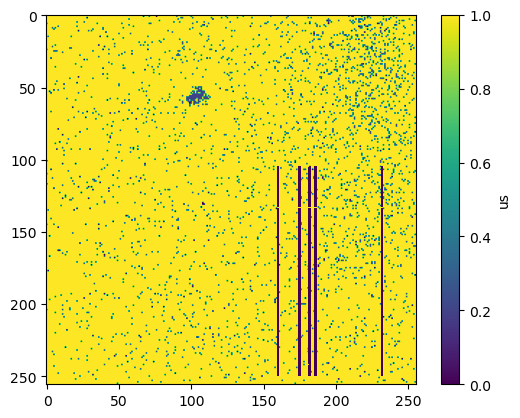

In [22]:
selcet_point = SELECT()
selcet_point.init_point(reset_path="../chip_data/chip8_/cond_250.npy",set_path="../chip_data/chip6_/cond_500.npy",value_stack_off=0.2,value_stack_on=-0.2)
selcet_point.add_used(path="../data/svm/weight_pos_128_5_chip_6_.npz")
plot_cond(selcet_point.good_point,vmax=1)

In [23]:
# row=[i for i in range(106,250)]
# col=[i for i in range(10,250)]
# ansrow,anscol=selcet_point.find_good_device(row,col,129,5)
# print(np.sort(ansrow))
# print(np.sort(anscol))
# sub_matrix = selcet_point.good_point[np.ix_(ansrow, anscol)]
# print(np.sum(sub_matrix))
# plot_cond(sub_matrix,vmax=1)
# selcet_point.save_pos(row=ansrow,col=anscol,file_path="../data/svm/weight_pos_128_5_chip_6_")

In [24]:
# 加载权重数据
Wb=np.load('../data/svm/svm_weight_90.npy').T
print(np.min(Wb),np.max(Wb))
layer=svmLayer(chip=chip,weight_target=Wb,weight_min=-4.5,weight_max=4.5,cond_min=0,cond_max=1100,cond_reference=550)
layer.set_weight_map_form_file("../data/svm/weight_pos_128_5_chip_6_.npz")

-3.957509136477504 4.5551797491647035


# 2. 写权重

In [ ]:
tg_map = np.array([1.5,1.55,1.6,1.65,1.7,1.75,1.8])
cond_map = np.array([350,390,450,490,550,590,650])
slope,intercept = np.polyfit(cond_map,tg_map, 1)

In [ ]:
threshold = 20

set_v,reset_v = 1,0.95
reset_pulse_width,set_pulse_width = 100e-6,100e-6
need_read = np.zeros((256,256),dtype=bool)
target = np.ones((256,256))

pos = layer.get_weight_pos()
need_read[pos] = True
target[pos] = layer.get_target_cond()
tg_v = target*slope+intercept-0.2
for k in range(1):
    for i in range(40):
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        resistence = chip.voltage_to_resistance(voltage = voltage-voltage_base)
        cond = chip.compensation.compensation_point(resistence=resistence,from_row=True,return_type=0)

        condition_reset = (cond > (target+threshold)) & need_read
        condition_set = (cond < (target-threshold)) & need_read
        plot_cond(cond[pos]-layer.cond_reference,vmin=-layer.cond_range,vmax=layer.cond_range,title=f"{i},reset:{np.sum(condition_reset)},set:{np.sum(condition_set)}")

        if i>0:
            # set_pulse_width = set_pulse_width+10e-6*i
            # reset_pulse_width = reset_pulse_width+10e-6*i
            # set_v+=0.1
            # reset_v+=0.1
            # tg_v[condition_set] +=0.05
            if i<10:
                tg_v[condition_reset] -= 0.04
                tg_v[condition_set] += 0.04
            else:
                tg_v[condition_reset] -= 0.02
                tg_v[condition_set] += 0.02

        tg_v.clip(0,4,out=tg_v)

        chip.write_point2(crossbar=condition_reset,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
        chip.write_point2(crossbar=condition_reset,write_voltage=set_v-0.5,tg=tg_v,pulse_width=set_pulse_width,set_device=True)
        # # # # chip.ps.set_time_out(100)
        chip.write_point2(crossbar=condition_set,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

    set_v = set_v+0.3
    reset_v = reset_v+0.05
    set_pulse_width = set_pulse_width+10e-6*k
    reset_pulse_width = reset_pulse_width+10e-6*k
    tg_v = target*slope+intercept+k*0.05-0.3

# 5.读出来的权重做推理

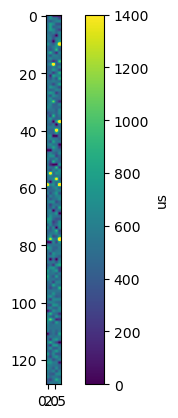

In [ ]:
cond = layer.read_cond_point(from_row=True)
# W = hnnLayer.read_weight_point(from_row=True)
W = (cond-layer.cond_reference)/layer.cond_range*layer.weight_max
plot_cond(cond)



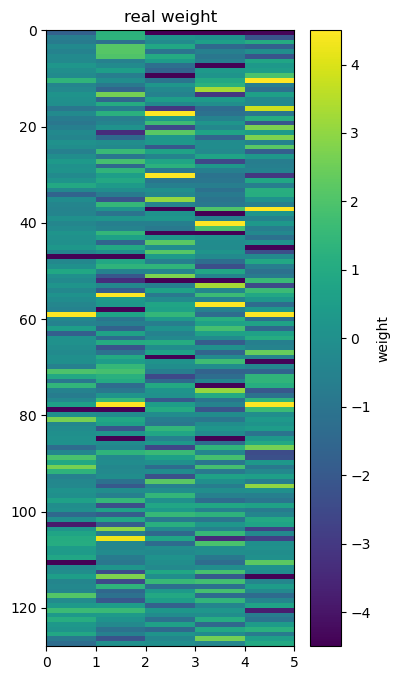

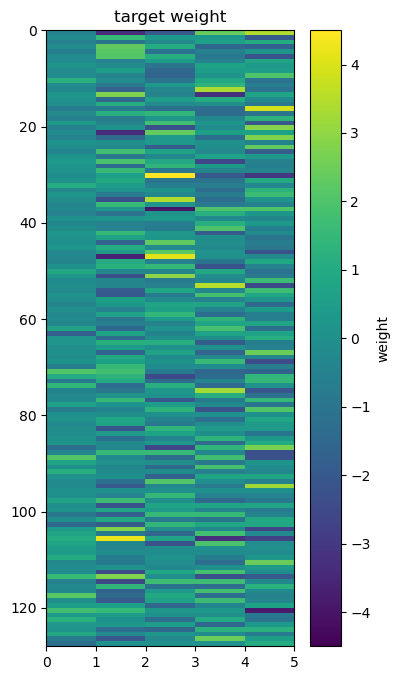

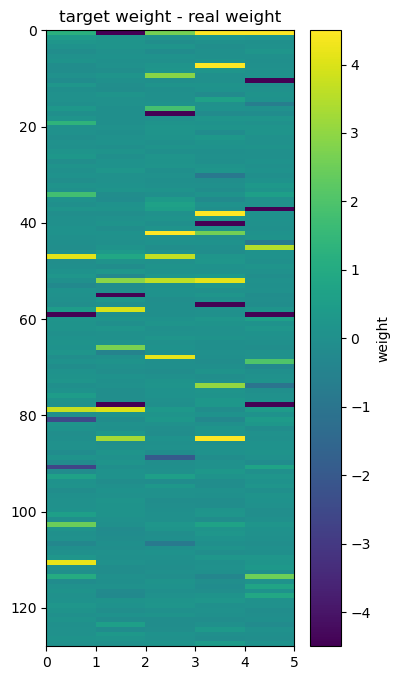

In [35]:
cmap = plt.cm.viridis
norm = Normalize(vmin=-4.5, vmax=4.5)

plt.figure(figsize=(4,8))
# extent = [left, right, bottom, top]
# 这里的 left 和 right 控制 x 轴的范围，从而调整每个像素的宽度
im = plt.imshow(W, cmap=cmap, norm=norm, extent=[0, 5, 128, 0], aspect='auto')
cbar = plt.colorbar(im)
cbar.set_label("weight")
plt.title("real weight")
plt.show()


plt.figure(figsize=(4,8))
# extent = [left, right, bottom, top]
# 这里的 left 和 right 控制 x 轴的范围，从而调整每个像素的宽度
im = plt.imshow(layer.weight_target, cmap=cmap, norm=norm, extent=[0, 5, 128, 0], aspect='auto')
cbar = plt.colorbar(im)
cbar.set_label("weight")
plt.title("target weight")
plt.show()

plt.figure(figsize=(4,8))
# extent = [left, right, bottom, top]
# 这里的 left 和 right 控制 x 轴的范围，从而调整每个像素的宽度
im = plt.imshow(layer.weight_target-W, cmap=cmap, norm=norm, extent=[0, 5, 128, 0], aspect='auto')
cbar = plt.colorbar(im)
cbar.set_label("weight")
plt.title("target weight - real weight")
plt.show()

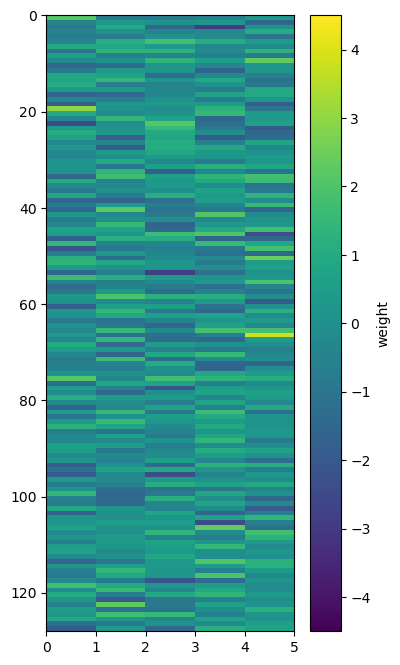

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# 示例数据
data = np.random.randn(128, 5)  # 示例数据，假设是 10x10 的数组
cmap = plt.cm.viridis
norm = Normalize(vmin=-4.5, vmax=4.5)

plt.figure(figsize=(4,8))

# extent = [left, right, bottom, top]
# 这里的 left 和 right 控制 x 轴的范围，从而调整每个像素的宽度
im = plt.imshow(data, cmap=cmap, norm=norm, extent=[0, 5, 128, 0], aspect='auto')

# 添加颜色条
cbar = plt.colorbar(im)
cbar.set_label("weight")

# 显示图像
plt.show()

In [ ]:
mat_contents = sio.loadmat('../data/svm/train3.mat')
data = mat_contents['train_3']  # 根据实际文件中的变量名调整

# 数据中前128列为特征，最后1列为标签（原始标签取值为 1~5）
X = data[:, :128]  # 特征矩阵，尺寸为 (N, d) 其中 d=128
Y = data[:, 128].flatten()-1  # 标签向量，尺寸为 (N, )
# 为方便运算，将标签调整到 0~K-1 （K=5）
N,d = X.shape
K = 5

# 生产新的输入
X_NEW = np.hstack((X, np.ones((N,1))))

In [ ]:
scores_all = np.dot(X_NEW, Wb)
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")


scores_all = np.dot(X_NEW, W)
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y)
print(f"Accuracy = {acc * 100:.2f}%")

In [ ]:
compensation_para:dict={
    "compensation_type":0,
    "value":0.7,
    "real_mean":550,
    "odd_offset":0,
    "even_offset":0,
    "odd_mult":1,
    "even_mult":1,
    "all_mult":1,
    "add_wire":True
}
layer.set_forward_paramater(forward_type=2,interval=60,compensation_para=compensation_para)

In [ ]:
select_num = 200
rows_to_select = np.random.choice(X_NEW.shape[0], select_num, replace=False)
X_SELECT = X_NEW[rows_to_select, :]
Y_SELECT = Y[rows_to_select]
print(X_SELECT.shape,Y_SELECT.shape)

In [ ]:
# np.savez("../data/svm/data.npz",x=x_select,y=y_select)
data = np.load("../data/svm/data2.npz")
x1 = data["x"]
y1 = data["y"]

select_num = 100
scores_all = np.zeros((select_num,5))

for i in range(select_num):
    scores_all[i,:]=layer.forward_from_row(x1[i])

y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == y1)
print(f"Accuracy = {acc * 100:.2f}%")

In [ ]:
scores_all = np.zeros((select_num,5))

for i in range(select_num):
    scores_all[i,:]=layer.forward_from_row(X_SELECT[i])

In [ ]:
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y_SELECT)
print(f"Accuracy = {acc * 100:.2f}%")

In [ ]:
import random
x_select=X_SELECT[y_pred == Y_SELECT][:100]
x_select[17] = X_SELECT[y_pred != Y_SELECT][0:1,:]
x_select[63] = X_SELECT[y_pred != Y_SELECT][1:2,:]
y_select = Y_SELECT[y_pred == Y_SELECT][:100]

y_select[17] = Y_SELECT[y_pred != Y_SELECT][0]
y_select[63] = Y_SELECT[y_pred != Y_SELECT][1]
# print(y_select.shape,Y_SELECT[y_pred != Y_SELECT][:5].shape)




print(x_select.shape,y_select.shape)
# np.savez("../data/svm/data2.npz",x=x_select,y=y_select)


In [ ]:
data = np.load("../data/svm/data.npz")
x1 = data["x"]
y1 = data["y"]


scores_all = np.dot(x1, Wb)
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == y1)
print(f"Accuracy = {acc * 100:.2f}%")

In [ ]:
compensation_para:dict={
    "value":0.785,
    "real_mean":550,
    "odd_offset":0,
    "even_offset":0,
    "odd_mult":1,
    "even_mult":1,
    "all_mult":1.1,
    "add_wire":True
}

In [ ]:
cond2 = layer.forward_unsigned_from_row(layer.row_index[:128],layer.col_index,forward_type=2,return_type=1,compensation_para=compensation_para)
cond0 = layer.forward_unsigned_from_row(layer.row_index[:128],layer.col_index,forward_type=3,return_type=1,compensation_para=compensation_para)
for i in range(5):
    print(cond0[i],cond2[i],cond0[i]-cond2[i],layer.col_index[i])

In [ ]:
compensation_para:dict={
    "value":0.7,
    "real_mean":550,
    "odd_offset":0,
    "even_offset":0,
    "odd_mult":1,
    "even_mult":1,
    "all_mult":1,
    "add_wire":True
}
import random
for col in range(0,5):
    ans = layer.calculate_error_from_row(random.sample(layer.row_index.tolist(), 100),[layer.col_index[col]],compensation_para=compensation_para)
    # ans = hnnLayer.calculate_error_from_row(hnnLayer.row_index.tolist(),[hnnLayer.col_index[col]],compensation_para=compensation_para)
    plt.plot(ans[:,0],label = "real")
    plt.plot(ans[:,1],label = "no Compensation")
    plt.plot(ans[:,2],label = "Compensation")
    plt.plot(ans[:,3],label = "Compensation")
    plt.title("col="+str(layer.col_index[col]))
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

In [ ]:
y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y_SELECT)
print(f"Accuracy = {acc * 100:.2f}%")